# Radar plots — Random split vs Cold-start

Single notebook for all KGs. **Pick the KG below**, then *Run All*.

Two panels: Test MRR and Independent-test MRR, comparing
*Random Split* / *Cold-Start Drugs* / *Cold-Start Diseases*.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import radar_plots as rp
from kg_configs import CONFIGS

# ===> PICK THE KG HERE: 'biokg' | 'hetionet' | 'shepkg' <===
KG = "shepkg"

cfg = CONFIGS[KG]
print(f"KG = {cfg.name}")

KG = shepkg


In [2]:
results = rp.parse_model_metrics(cfg.coldstart_experiments, cfg)

# Sanity check
for exp in results:
    print(exp, "-> best models:", rp.order_models(results[exp]["best"], cfg.model_order, verbose=False))

random_split -> best models: ['ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']
cold_start_drugs -> best models: ['ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']
cold_start_diseases -> best models: ['ANALOGY', 'ComplEx', 'HolE', 'RESCAL', 'DistMult', 'TransE', 'TransD']


## Figure — two panels

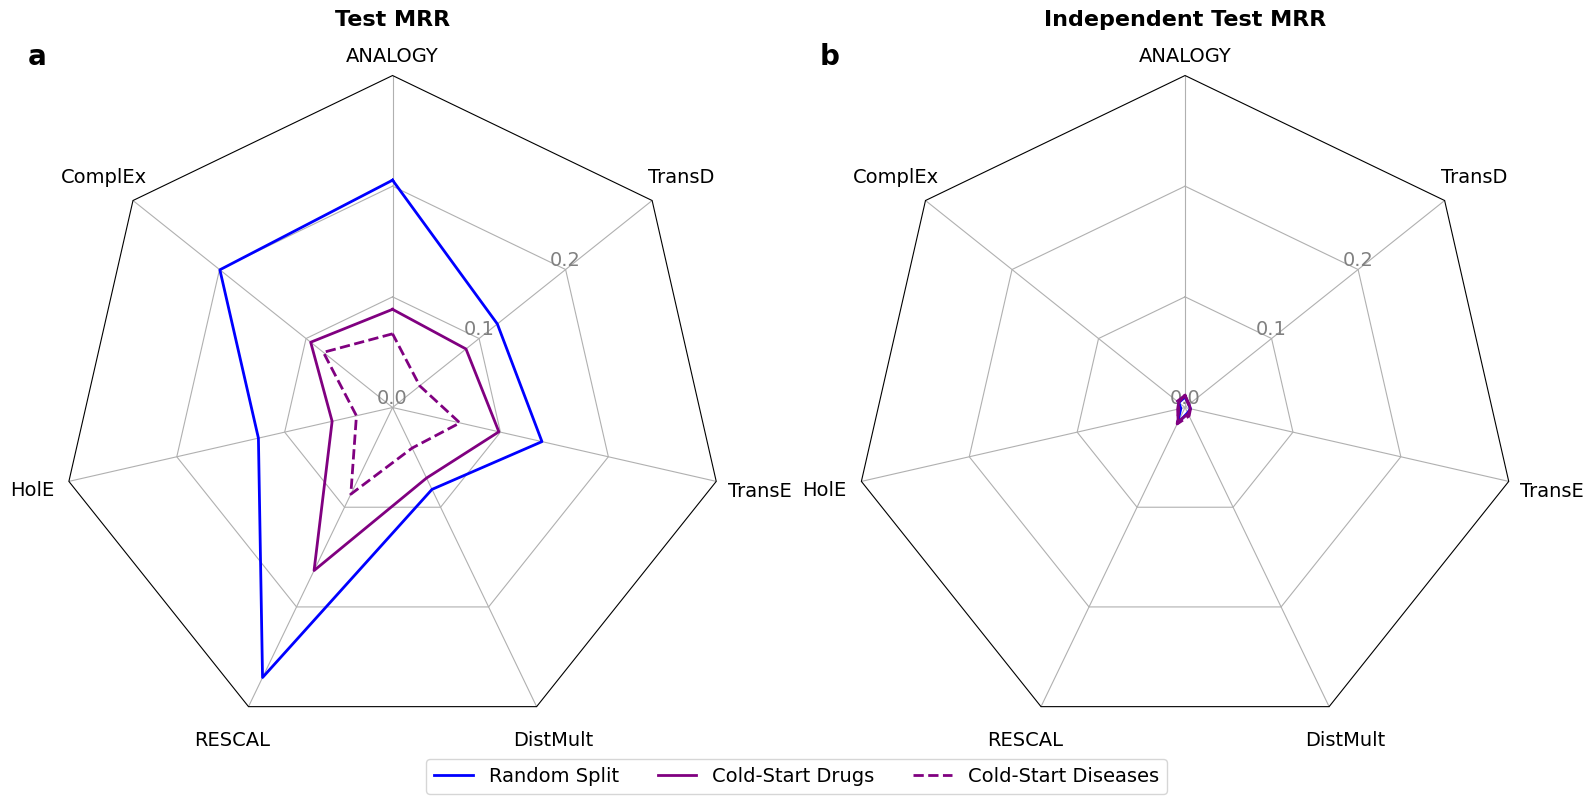

In [3]:
experiments = ["random_split", "cold_start_drugs", "cold_start_diseases"]
labels      = ["Random Split", "Cold-Start Drugs", "Cold-Start Diseases"]
colors      = ["blue", "purple", "purple"]
linestyles  = ["-", "-", "--"]
run         = "best"
y_lim       = cfg.ylims["coldstart"]
rgrid       = np.arange(0, y_lim, 0.1)

models = rp.order_models(results[experiments[0]][run], cfg.model_order, verbose=False)
rp.radar_factory(len(models), frame="polygon")

fig, axes = plt.subplots(1, 2, figsize=(16, 8), subplot_kw=dict(projection="radar"))

rp.plot_radar_3way(results, experiments, run, metric="target_relations",
                   legend_labels=labels, colors=colors, linestyles=linestyles,
                   model_order=cfg.model_order, y_lim=y_lim, rgrid=rgrid,
                   title="Test MRR", panel_label="a", ax=axes[0])

rp.plot_radar_3way(results, experiments, run, metric="inference_mrr",
                   legend_labels=labels, colors=colors, linestyles=linestyles,
                   model_order=cfg.model_order, y_lim=y_lim, rgrid=rgrid,
                   title="Independent Test MRR", panel_label="b", ax=axes[1])

# Shared legend at the bottom
handles, leg_labels = axes[0].get_legend_handles_labels()
fig.legend(handles, leg_labels, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=3, fontsize=14, frameon=True)

fig.tight_layout()
fig.savefig(f"{cfg.figures_dir}/radar_random_vs_coldstart_{cfg.name}.pdf", bbox_inches="tight")
fig.savefig(f"{cfg.figures_dir}/radar_random_vs_coldstart_{cfg.name}.png", dpi=200, bbox_inches="tight")
plt.show()